In [17]:
# ==========================================================
# Potato Leaf Feature Extraction Pipeline for LVQ
# Extracts color + texture + lesion + shape features
# ==========================================================

import cv2
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.measure import label, regionprops
from sklearn.preprocessing import StandardScaler
import os
import glob
from tqdm import tqdm

# ==========================================================
# SETTINGS
# ==========================================================

IMAGE_FOLDER = "Croptimal/resnet/"     # folder containing images
IMG_SIZE = (256, 256)

# ==========================================================
# HELPERS
# ==========================================================

def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    return img

# ----------------------------------------------------------
# Segment leaf from background
# ----------------------------------------------------------
def segment_leaf(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

    # Green leaf mask
    lower = np.array([20, 30, 20])
    upper = np.array([90, 255, 255])

    mask = cv2.inRange(hsv, lower, upper)

    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask

# ----------------------------------------------------------
# COLOR FEATURES
# ----------------------------------------------------------
def color_features(img, mask):
    pixels = img[mask > 0]

    R = pixels[:,0]
    G = pixels[:,1]
    B = pixels[:,2]

    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    hsv_pixels = hsv[mask > 0]

    H = hsv_pixels[:,0]
    S = hsv_pixels[:,1]

    mean_g = np.mean(G)
    std_g = np.std(G)
    mean_h = np.mean(H)
    mean_s = np.mean(S)

    # Yellow pixels
    yellow = np.sum((H > 20) & (H < 40))
    pct_yellow = yellow / len(H)

    # Brown pixels
    brown = np.sum((R > 100) & (G < 120) & (B < 80))
    pct_brown = brown / len(H)

    return [
        mean_g,
        std_g,
        mean_h,
        mean_s,
        pct_yellow,
        pct_brown
    ]

# ----------------------------------------------------------
# TEXTURE FEATURES
# ----------------------------------------------------------
def texture_features(img, mask):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.bitwise_and(gray, gray, mask=mask)

    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, 'contrast')[0,0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0,0]
    energy = graycoprops(glcm, 'energy')[0,0]
    correlation = graycoprops(glcm, 'correlation')[0,0]

    # entropy
    p = glcm[:,:,0,0]
    entropy = -np.sum(p * np.log2(p + 1e-10))

    # LBP variance
    lbp = local_binary_pattern(gray, 8, 1, method='uniform')
    lbp_var = np.var(lbp)

    return [
        contrast,
        homogeneity,
        energy,
        correlation,
        entropy,
        lbp_var
    ]

# ----------------------------------------------------------
# LESION FEATURES
# ----------------------------------------------------------
def lesion_features(img, mask):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

    # Detect brown/dark lesions
    lesion_mask = cv2.inRange(hsv,
                              np.array([0, 20, 20]),
                              np.array([30, 255, 180]))

    lesion_mask = cv2.bitwise_and(lesion_mask, lesion_mask, mask=mask)

    labels = label(lesion_mask)
    props = regionprops(labels)

    num_spots = len(props)

    if num_spots == 0:
        return [0,0,0,0,0]

    areas = [p.area for p in props]
    perims = [p.perimeter for p in props]

    largest = np.max(areas)
    avg_area = np.mean(areas)

    infected_ratio = np.sum(lesion_mask > 0) / np.sum(mask > 0)

    circularities = []
    for a, p in zip(areas, perims):
        if p > 0:
            circ = (4*np.pi*a)/(p**2)
            circularities.append(circ)

    mean_circ = np.mean(circularities) if circularities else 0

    return [
        num_spots,
        largest,
        avg_area,
        infected_ratio,
        mean_circ
    ]

# ----------------------------------------------------------
# SHAPE FEATURES
# ----------------------------------------------------------
def shape_features(mask):
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)

    if len(cnts) == 0:
        return [0,0,0]

    c = max(cnts, key=cv2.contourArea)

    area = cv2.contourArea(c)
    hull = cv2.convexHull(c)
    hull_area = cv2.contourArea(hull)

    solidity = area / hull_area if hull_area > 0 else 0

    x,y,w,h = cv2.boundingRect(c)
    aspect_ratio = w / h

    return [
        area,
        solidity,
        aspect_ratio
    ]

# ==========================================================
# MAIN FEATURE EXTRACTOR
# ==========================================================
def extract_features(path):
    img = load_image(path)
    mask = segment_leaf(img)

    feats = []
    feats.extend(color_features(img, mask))
    feats.extend(texture_features(img, mask))
    feats.extend(lesion_features(img, mask))
    feats.extend(shape_features(mask))

    return feats

# ==========================================================
# PROCESS DATASET
# ==========================================================
def run_pipeline(path):
    files = glob.glob(os.path.join(path, "*.png"))

    X = []
    names = []

    for f in tqdm(files):
        try:
            feat = extract_features(f)
            X.append(feat)
            names.append(os.path.basename(f))
            # print("Processed:", f)
        except:
            print("Failed:", f)

    X = np.array(X)

    # ==========================================================
    # NORMALIZE FOR LVQ
    # ==========================================================
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Save CSV
    df = pd.DataFrame(X_scaled)
    df.insert(0, "filename", names)
    save_path = "_".join(path.split('/')[2:])
    df.to_csv(f"{save_path}_potato_leaf_features.csv", index=False)

    print("Saved feature matrix:", X_scaled.shape)

In [18]:
run_pipeline("Croptimal/resnet/train/256_class_0")
run_pipeline("Croptimal/resnet/train/256_class_1")
run_pipeline("Croptimal/resnet/val/256_class_0")
run_pipeline("Croptimal/resnet/val/256_class_1")

  0%|          | 0/2258 [00:00<?, ?it/s]

100%|██████████| 2258/2258 [01:35<00:00, 23.62it/s]


Saved feature matrix: (2258, 20)


100%|██████████| 1390/1390 [00:49<00:00, 28.05it/s]


Saved feature matrix: (1390, 20)


100%|██████████| 458/458 [00:19<00:00, 23.69it/s]


Saved feature matrix: (458, 20)


100%|██████████| 288/288 [00:10<00:00, 26.49it/s]

Saved feature matrix: (288, 20)


/tmp/ipykernel_19464/2337038954.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=["class 0", "class 1"])
/tmp/ipykernel_19464/2337038954.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=["class 0", "class 1"])
/tmp/ipykernel_19464/2337038954.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=["class 0", "class 1"])
/tmp/ipykernel_19464/2337038954.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropp

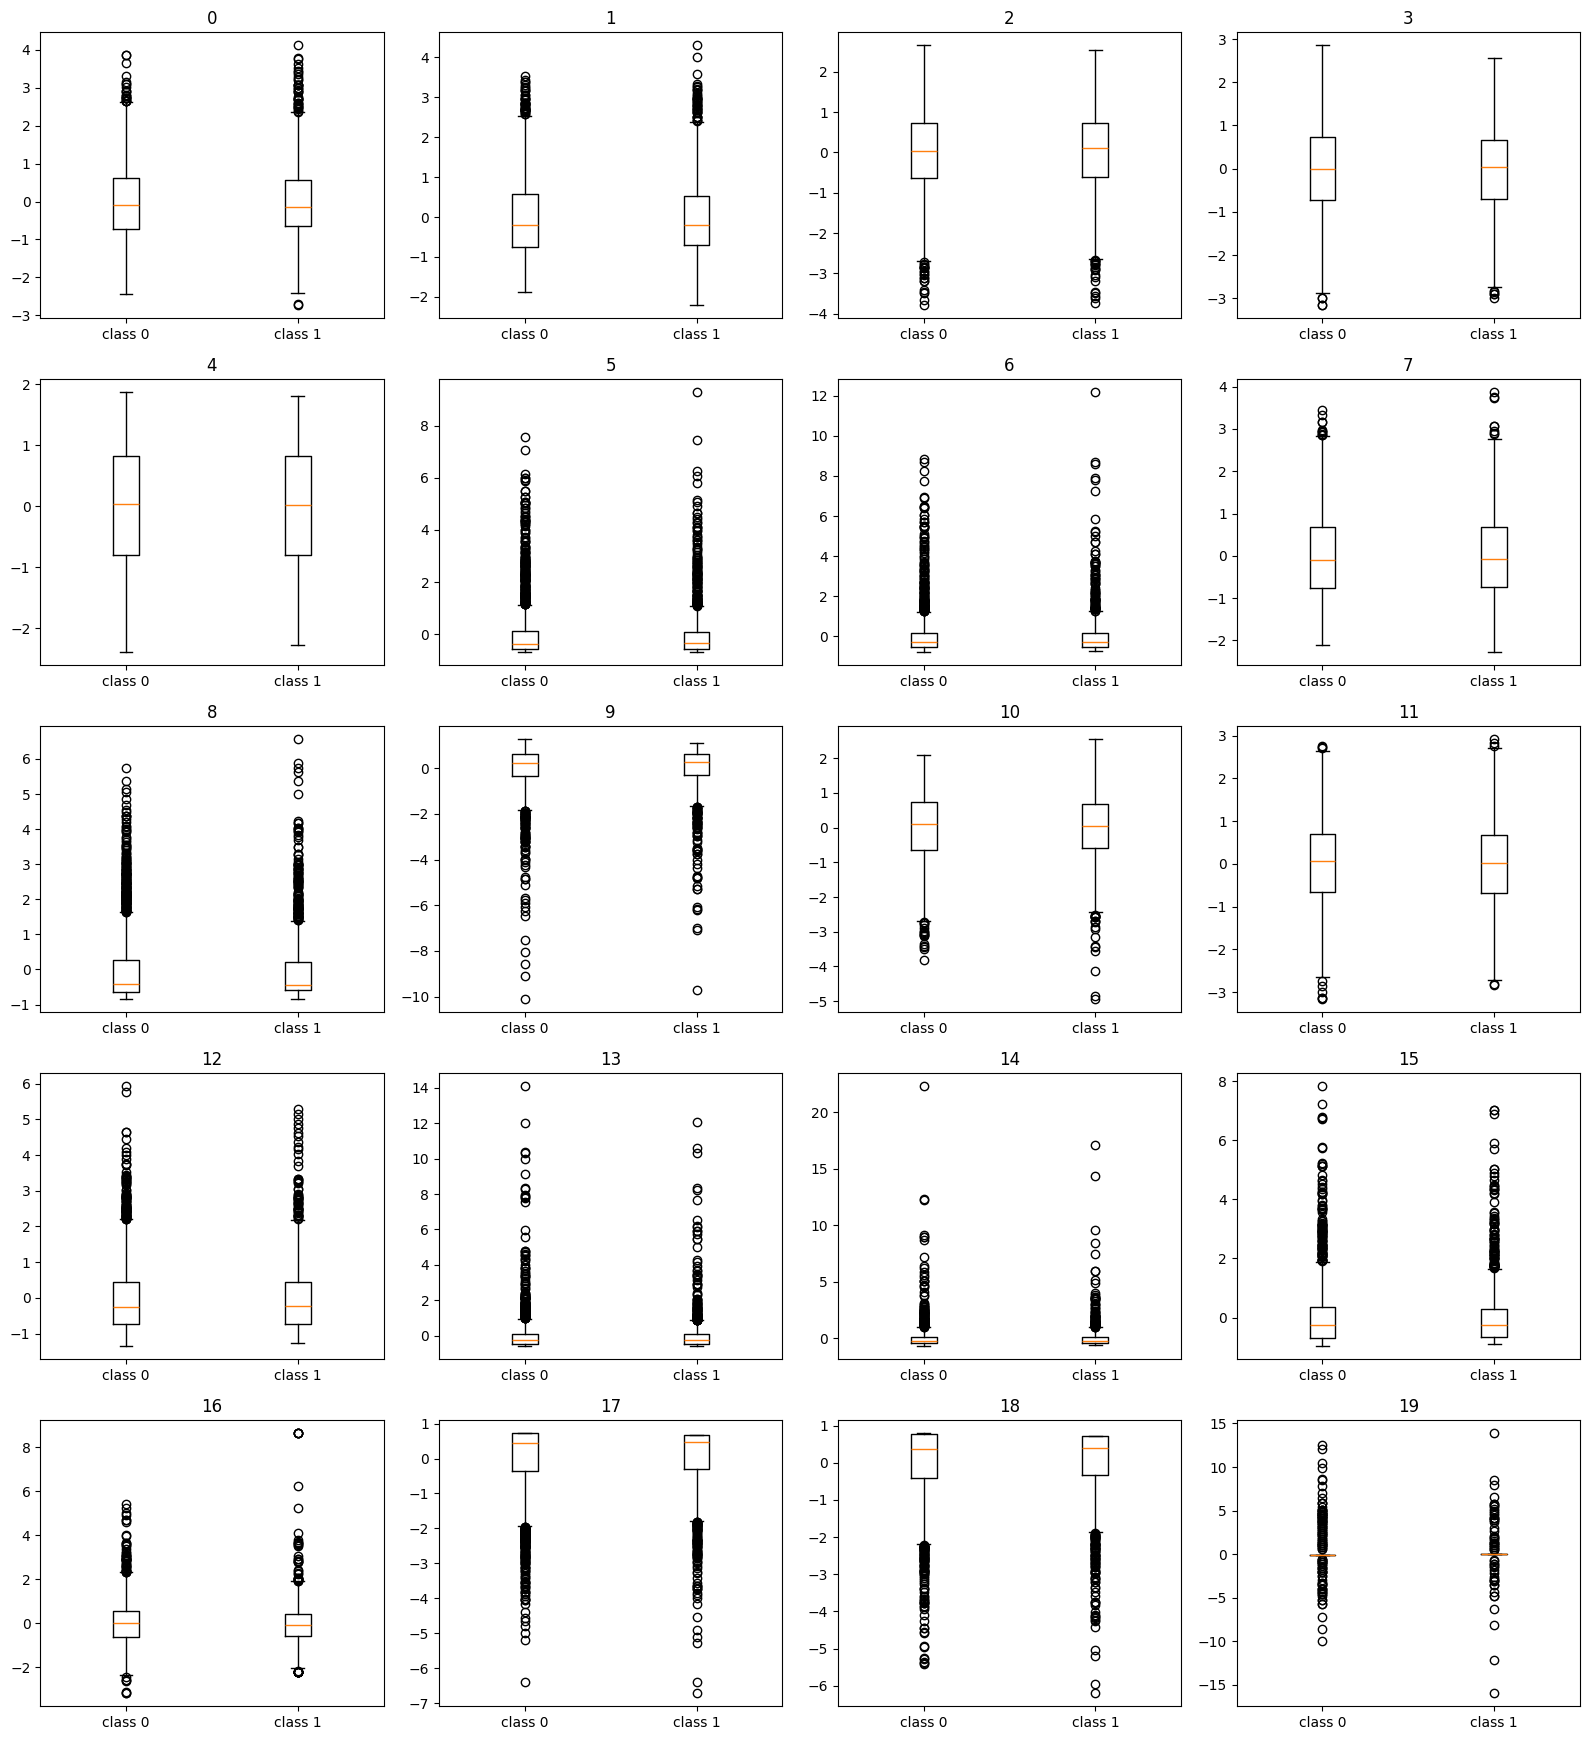

In [19]:
import pandas as pd

import matplotlib.pyplot as plt

# Load feature files
df0 = pd.read_csv("train_256_class_0_potato_leaf_features.csv")
df1 = pd.read_csv("train_256_class_1_potato_leaf_features.csv")

df0["class"] = "class 0"
df1["class"] = "class 1"

df = pd.concat([df0, df1], ignore_index=True)

# Feature columns (exclude filename and class)
feature_cols = [c for c in df.columns if c not in ["filename", "class"]]

# Plot each feature as a boxplot comparing class 0 vs class 1
n_features = len(feature_cols)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(feature_cols):
    ax = axes[i]
    data0 = df[df["class"] == "class 0"][feature].dropna()
    data1 = df[df["class"] == "class 1"][feature].dropna()

    ax.boxplot([data0, data1], labels=["class 0", "class 1"])
    ax.set_title(feature)
    ax.tick_params(axis="x", rotation=0)

# Hide unused subplots
for j in range(n_features, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [22]:
# ==========================================================
# Statistical Comparison of Class 0 vs Class 1 Features
# Files:
#   train_256_class_0_potato_leaf_features.csv
#   train_256_class_1_potato_leaf_features.csv
#
# Compares each of 20 features using:
#   1. Shapiro normality test
#   2. Welch t-test (parametric)
#   3. Mann-Whitney U test (nonparametric)
#   4. Cohen's d effect size
#   5. Multiple-comparison correction (Benjamini-Hochberg)
# ==========================================================

import pandas as pd
import numpy as np
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ==========================================================
# LOAD FILES
# ==========================================================

file0 = "train_256_class_0_potato_leaf_features.csv"
file1 = "train_256_class_1_potato_leaf_features.csv"

df0 = pd.read_csv(file0)
df1 = pd.read_csv(file1)

print("Class 0 shape:", df0.shape)
print("Class 1 shape:", df1.shape)

# ----------------------------------------------------------
# Remove filename column if present
# ----------------------------------------------------------
for col in ["filename", "image", "name"]:
    if col in df0.columns:
        df0 = df0.drop(columns=[col])
    if col in df1.columns:
        df1 = df1.drop(columns=[col])

# ==========================================================
# CHECK FEATURE COUNT
# ==========================================================

assert df0.shape[1] == df1.shape[1], "Feature counts do not match!"
assert df0.shape[1] == 20, f"Expected 20 features, got {df0.shape[1]}"

feature_names = df0.columns.tolist()

# ==========================================================
# EFFECT SIZE
# ==========================================================
def cohens_d(x, y):
    nx = len(x)
    ny = len(y)

    pooled_std = np.sqrt(
        ((nx - 1)*np.var(x, ddof=1) + (ny - 1)*np.var(y, ddof=1))
        / (nx + ny - 2)
    )

    if pooled_std == 0:
        return 0

    return (np.mean(x) - np.mean(y)) / pooled_std

# ==========================================================
# ANALYSIS LOOP
# ==========================================================

results = []

for feat in feature_names:

    x = df0[feat].dropna().values
    y = df1[feat].dropna().values

    # Normality tests
    p_norm_x = shapiro(x[:5000])[1] if len(x) >= 3 else np.nan
    p_norm_y = shapiro(y[:5000])[1] if len(y) >= 3 else np.nan

    # Welch t-test
    t_stat, p_t = ttest_ind(x, y, equal_var=False)

    # Mann-Whitney U
    u_stat, p_u = mannwhitneyu(x, y, alternative='two-sided')

    # Effect size
    d = cohens_d(x, y)

    results.append({
        "feature": feat,
        "mean_class0": np.mean(x),
        "std_class0": np.std(x, ddof=1),
        "mean_class1": np.mean(y),
        "std_class1": np.std(y, ddof=1),
        "normality_p_class0": p_norm_x,
        "normality_p_class1": p_norm_y,
        "t_pvalue": p_t,
        "mw_pvalue": p_u,
        "cohens_d": d
    })

# ==========================================================
# MULTIPLE TEST CORRECTION
# ==========================================================

res_df = pd.DataFrame(results)

# Benjamini-Hochberg correction
res_df["t_p_adj"] = multipletests(res_df["t_pvalue"], method="fdr_bh")[1]
res_df["mw_p_adj"] = multipletests(res_df["mw_pvalue"], method="fdr_bh")[1]

# Significant flags
res_df["t_significant"] = res_df["t_p_adj"] < 0.05
res_df["mw_significant"] = res_df["mw_p_adj"] < 0.05

# Sort by strongest significance
res_df = res_df.sort_values("mw_p_adj")

# ==========================================================
# SAVE RESULTS
# ==========================================================

res_df.to_csv("class0_vs_class1_statistics.csv", index=False)

print("\nSaved results to class0_vs_class1_statistics.csv")

# ==========================================================
# DISPLAY SUMMARY
# ==========================================================

print("\nTop Significant Features:")
print(
    res_df[
        ["feature", "mean_class0", "mean_class1",
         "mw_p_adj", "cohens_d"]
    ].head(10)
)

print("\nTotal Significant Features (MW corrected):",
      res_df["mw_significant"].sum())

Class 0 shape: (2258, 21)
Class 1 shape: (1390, 21)

Saved results to class0_vs_class1_statistics.csv

Top Significant Features:
   feature   mean_class0   mean_class1  mw_p_adj      cohens_d
19      19 -6.551594e-15  4.089455e-15  0.000000 -1.063813e-14
17      17  1.982471e-16  3.910541e-16  0.000006 -1.927541e-16
18      18  1.789888e-14  1.911053e-14  0.000182 -1.211320e-15
8        8  5.695670e-16  6.313096e-16  0.218047 -6.172560e-17
16      16  6.104752e-15 -4.984023e-17  0.894756  6.152904e-15
6        6 -2.452128e-15  1.058785e-15  0.894756 -3.509950e-15
2        2  5.596547e-15  1.354376e-14  0.952339 -7.945037e-15
0        0 -9.314466e-16 -3.087538e-15  0.952339  2.155500e-15
7        7  5.277149e-15  2.658145e-15  0.952339  2.618285e-15
9        9  3.370515e-14  1.462951e-13  0.952339 -1.125591e-13

Total Significant Features (MW corrected): 3


In [23]:
# ==========================================================
# Statistical Comparison of Class 0 vs Class 1 Features
# Files:
#   val_256_class_0_potato_leaf_features.csv
#   val_256_class_1_potato_leaf_features.csv
#
# Compares each of 20 features using:
#   1. Shapiro normality test
#   2. Welch t-test (parametric)
#   3. Mann-Whitney U test (nonparametric)
#   4. Cohen's d effect size
#   5. Multiple-comparison correction (Benjamini-Hochberg)
# ==========================================================

import pandas as pd
import numpy as np
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ==========================================================
# LOAD FILES
# ==========================================================

file0 = "val_256_class_0_potato_leaf_features.csv"
file1 = "val_256_class_1_potato_leaf_features.csv"

df0 = pd.read_csv(file0)
df1 = pd.read_csv(file1)

print("Class 0 shape:", df0.shape)
print("Class 1 shape:", df1.shape)

# ----------------------------------------------------------
# Remove filename column if present
# ----------------------------------------------------------
for col in ["filename", "image", "name"]:
    if col in df0.columns:
        df0 = df0.drop(columns=[col])
    if col in df1.columns:
        df1 = df1.drop(columns=[col])

# ==========================================================
# CHECK FEATURE COUNT
# ==========================================================

assert df0.shape[1] == df1.shape[1], "Feature counts do not match!"
assert df0.shape[1] == 20, f"Expected 20 features, got {df0.shape[1]}"

feature_names = df0.columns.tolist()

# ==========================================================
# EFFECT SIZE
# ==========================================================
def cohens_d(x, y):
    nx = len(x)
    ny = len(y)

    pooled_std = np.sqrt(
        ((nx - 1)*np.var(x, ddof=1) + (ny - 1)*np.var(y, ddof=1))
        / (nx + ny - 2)
    )

    if pooled_std == 0:
        return 0

    return (np.mean(x) - np.mean(y)) / pooled_std

# ==========================================================
# ANALYSIS LOOP
# ==========================================================

results = []

for feat in feature_names:

    x = df0[feat].dropna().values
    y = df1[feat].dropna().values

    # Normality tests
    p_norm_x = shapiro(x[:5000])[1] if len(x) >= 3 else np.nan
    p_norm_y = shapiro(y[:5000])[1] if len(y) >= 3 else np.nan

    # Welch t-test
    t_stat, p_t = ttest_ind(x, y, equal_var=False)

    # Mann-Whitney U
    u_stat, p_u = mannwhitneyu(x, y, alternative='two-sided')

    # Effect size
    d = cohens_d(x, y)

    results.append({
        "feature": feat,
        "mean_class0": np.mean(x),
        "std_class0": np.std(x, ddof=1),
        "mean_class1": np.mean(y),
        "std_class1": np.std(y, ddof=1),
        "normality_p_class0": p_norm_x,
        "normality_p_class1": p_norm_y,
        "t_pvalue": p_t,
        "mw_pvalue": p_u,
        "cohens_d": d
    })

# ==========================================================
# MULTIPLE TEST CORRECTION
# ==========================================================

res_df = pd.DataFrame(results)

# Benjamini-Hochberg correction
res_df["t_p_adj"] = multipletests(res_df["t_pvalue"], method="fdr_bh")[1]
res_df["mw_p_adj"] = multipletests(res_df["mw_pvalue"], method="fdr_bh")[1]

# Significant flags
res_df["t_significant"] = res_df["t_p_adj"] < 0.05
res_df["mw_significant"] = res_df["mw_p_adj"] < 0.05

# Sort by strongest significance
res_df = res_df.sort_values("mw_p_adj")

# ==========================================================
# SAVE RESULTS
# ==========================================================

res_df.to_csv("class0_vs_class1_statistics.csv", index=False)

print("\nSaved results to class0_vs_class1_statistics.csv")

# ==========================================================
# DISPLAY SUMMARY
# ==========================================================

print("\nTop Significant Features:")
print(
    res_df[
        ["feature", "mean_class0", "mean_class1",
         "mw_p_adj", "cohens_d"]
    ].head(10)
)

print("\nTotal Significant Features (MW corrected):",
      res_df["mw_significant"].sum())

Class 0 shape: (458, 21)
Class 1 shape: (288, 21)

Saved results to class0_vs_class1_statistics.csv

Top Significant Features:
   feature   mean_class0   mean_class1       mw_p_adj      cohens_d
19      19  4.305144e-15  1.142605e-14  1.842010e-128 -7.111349e-15
14      14  1.372992e-15 -2.960595e-16   1.401506e-03  1.666813e-15
17      17  4.654210e-17 -2.467162e-16   2.384166e-02  2.928650e-16
18      18 -5.821641e-15 -9.344377e-16   2.384166e-02 -4.880648e-15
4        4  1.215912e-15  1.851914e-15   9.764747e-01 -6.351482e-16
0        0 -1.644488e-15  6.599659e-16   9.764747e-01 -2.301362e-15
2        2 -7.877251e-15 -8.386810e-15   9.764747e-01  5.088757e-16
1        1  6.612857e-16  8.079956e-16   9.764747e-01 -1.465132e-16
7        7  1.415656e-15  1.727014e-16   9.764747e-01  1.241287e-15
8        8  3.878508e-16 -8.542549e-16   9.764747e-01  1.240440e-15

Total Significant Features (MW corrected): 4


In [24]:
# ==========================================================
# Statistical Comparison of Class 0 vs Class 1 Features
# Files:
#   train_256_class_0_potato_leaf_features.csv
#   val_256_class_0_potato_leaf_features.csv
#
# Compares each of 20 features using:
#   1. Shapiro normality test
#   2. Welch t-test (parametric)
#   3. Mann-Whitney U test (nonparametric)
#   4. Cohen's d effect size
#   5. Multiple-comparison correction (Benjamini-Hochberg)
# ==========================================================

import pandas as pd
import numpy as np
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ==========================================================
# LOAD FILES
# ==========================================================

file0 = "train_256_class_0_potato_leaf_features.csv"
file1 = "val_256_class_0_potato_leaf_features.csv"

df0 = pd.read_csv(file0)
df1 = pd.read_csv(file1)

print("Class 0 shape:", df0.shape)
print("Class 1 shape:", df1.shape)

# ----------------------------------------------------------
# Remove filename column if present
# ----------------------------------------------------------
for col in ["filename", "image", "name"]:
    if col in df0.columns:
        df0 = df0.drop(columns=[col])
    if col in df1.columns:
        df1 = df1.drop(columns=[col])

# ==========================================================
# CHECK FEATURE COUNT
# ==========================================================

assert df0.shape[1] == df1.shape[1], "Feature counts do not match!"
assert df0.shape[1] == 20, f"Expected 20 features, got {df0.shape[1]}"

feature_names = df0.columns.tolist()

# ==========================================================
# EFFECT SIZE
# ==========================================================
def cohens_d(x, y):
    nx = len(x)
    ny = len(y)

    pooled_std = np.sqrt(
        ((nx - 1)*np.var(x, ddof=1) + (ny - 1)*np.var(y, ddof=1))
        / (nx + ny - 2)
    )

    if pooled_std == 0:
        return 0

    return (np.mean(x) - np.mean(y)) / pooled_std

# ==========================================================
# ANALYSIS LOOP
# ==========================================================

results = []

for feat in feature_names:

    x = df0[feat].dropna().values
    y = df1[feat].dropna().values

    # Normality tests
    p_norm_x = shapiro(x[:5000])[1] if len(x) >= 3 else np.nan
    p_norm_y = shapiro(y[:5000])[1] if len(y) >= 3 else np.nan

    # Welch t-test
    t_stat, p_t = ttest_ind(x, y, equal_var=False)

    # Mann-Whitney U
    u_stat, p_u = mannwhitneyu(x, y, alternative='two-sided')

    # Effect size
    d = cohens_d(x, y)

    results.append({
        "feature": feat,
        "mean_class0": np.mean(x),
        "std_class0": np.std(x, ddof=1),
        "mean_class1": np.mean(y),
        "std_class1": np.std(y, ddof=1),
        "normality_p_class0": p_norm_x,
        "normality_p_class1": p_norm_y,
        "t_pvalue": p_t,
        "mw_pvalue": p_u,
        "cohens_d": d
    })

# ==========================================================
# MULTIPLE TEST CORRECTION
# ==========================================================

res_df = pd.DataFrame(results)

# Benjamini-Hochberg correction
res_df["t_p_adj"] = multipletests(res_df["t_pvalue"], method="fdr_bh")[1]
res_df["mw_p_adj"] = multipletests(res_df["mw_pvalue"], method="fdr_bh")[1]

# Significant flags
res_df["t_significant"] = res_df["t_p_adj"] < 0.05
res_df["mw_significant"] = res_df["mw_p_adj"] < 0.05

# Sort by strongest significance
res_df = res_df.sort_values("mw_p_adj")

# ==========================================================
# SAVE RESULTS
# ==========================================================

res_df.to_csv("class0_vs_class1_statistics.csv", index=False)

print("\nSaved results to class0_vs_class1_statistics.csv")

# ==========================================================
# DISPLAY SUMMARY
# ==========================================================

print("\nTop Significant Features:")
print(
    res_df[
        ["feature", "mean_class0", "mean_class1",
         "mw_p_adj", "cohens_d"]
    ].head(10)
)

print("\nTotal Significant Features (MW corrected):",
      res_df["mw_significant"].sum())

Class 0 shape: (2258, 21)
Class 1 shape: (458, 21)

Saved results to class0_vs_class1_statistics.csv

Top Significant Features:
   feature   mean_class0   mean_class1  mw_p_adj      cohens_d
19      19 -6.551594e-15  4.305144e-15  0.000000 -1.085274e-14
14      14 -1.944710e-15  1.372992e-15  0.000890 -3.316480e-15
17      17  1.982471e-16  4.654210e-17  0.015431  1.516491e-16
5        5 -1.510454e-16 -2.278624e-16  0.015431  7.678868e-17
18      18  1.789888e-14 -5.821641e-15  0.015431  2.371179e-14
13      13 -1.258712e-17  3.296732e-17  0.071065 -4.553766e-17
3        3 -7.399651e-15 -5.356220e-15  0.974845 -2.042679e-15
0        0 -9.314466e-16 -1.644488e-15  0.974845  7.127783e-16
7        7  5.277149e-15  1.415656e-15  0.974845  3.860071e-15
6        6 -2.452128e-15  1.628974e-16  0.974845 -2.614062e-15

Total Significant Features (MW corrected): 5


In [25]:
# ==========================================================
# Statistical Comparison of Class 0 vs Class 1 Features
# Files:
#   train_256_class_1_potato_leaf_features.csv
#   val_256_class_1_potato_leaf_features.csv
#
# Compares each of 20 features using:
#   1. Shapiro normality test
#   2. Welch t-test (parametric)
#   3. Mann-Whitney U test (nonparametric)
#   4. Cohen's d effect size
#   5. Multiple-comparison correction (Benjamini-Hochberg)
# ==========================================================

import pandas as pd
import numpy as np
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ==========================================================
# LOAD FILES
# ==========================================================

file0 = "train_256_class_1_potato_leaf_features.csv"
file1 = "val_256_class_1_potato_leaf_features.csv"

df0 = pd.read_csv(file0)
df1 = pd.read_csv(file1)

print("Class 0 shape:", df0.shape)
print("Class 1 shape:", df1.shape)

# ----------------------------------------------------------
# Remove filename column if present
# ----------------------------------------------------------
for col in ["filename", "image", "name"]:
    if col in df0.columns:
        df0 = df0.drop(columns=[col])
    if col in df1.columns:
        df1 = df1.drop(columns=[col])

# ==========================================================
# CHECK FEATURE COUNT
# ==========================================================

assert df0.shape[1] == df1.shape[1], "Feature counts do not match!"
assert df0.shape[1] == 20, f"Expected 20 features, got {df0.shape[1]}"

feature_names = df0.columns.tolist()

# ==========================================================
# EFFECT SIZE
# ==========================================================
def cohens_d(x, y):
    nx = len(x)
    ny = len(y)

    pooled_std = np.sqrt(
        ((nx - 1)*np.var(x, ddof=1) + (ny - 1)*np.var(y, ddof=1))
        / (nx + ny - 2)
    )

    if pooled_std == 0:
        return 0

    return (np.mean(x) - np.mean(y)) / pooled_std

# ==========================================================
# ANALYSIS LOOP
# ==========================================================

results = []

for feat in feature_names:

    x = df0[feat].dropna().values
    y = df1[feat].dropna().values

    # Normality tests
    p_norm_x = shapiro(x[:5000])[1] if len(x) >= 3 else np.nan
    p_norm_y = shapiro(y[:5000])[1] if len(y) >= 3 else np.nan

    # Welch t-test
    t_stat, p_t = ttest_ind(x, y, equal_var=False)

    # Mann-Whitney U
    u_stat, p_u = mannwhitneyu(x, y, alternative='two-sided')

    # Effect size
    d = cohens_d(x, y)

    results.append({
        "feature": feat,
        "mean_class0": np.mean(x),
        "std_class0": np.std(x, ddof=1),
        "mean_class1": np.mean(y),
        "std_class1": np.std(y, ddof=1),
        "normality_p_class0": p_norm_x,
        "normality_p_class1": p_norm_y,
        "t_pvalue": p_t,
        "mw_pvalue": p_u,
        "cohens_d": d
    })

# ==========================================================
# MULTIPLE TEST CORRECTION
# ==========================================================

res_df = pd.DataFrame(results)

# Benjamini-Hochberg correction
res_df["t_p_adj"] = multipletests(res_df["t_pvalue"], method="fdr_bh")[1]
res_df["mw_p_adj"] = multipletests(res_df["mw_pvalue"], method="fdr_bh")[1]

# Significant flags
res_df["t_significant"] = res_df["t_p_adj"] < 0.05
res_df["mw_significant"] = res_df["mw_p_adj"] < 0.05

# Sort by strongest significance
res_df = res_df.sort_values("mw_p_adj")

# ==========================================================
# SAVE RESULTS
# ==========================================================

res_df.to_csv("class0_vs_class1_statistics.csv", index=False)

print("\nSaved results to class0_vs_class1_statistics.csv")

# ==========================================================
# DISPLAY SUMMARY
# ==========================================================

print("\nTop Significant Features:")
print(
    res_df[
        ["feature", "mean_class0", "mean_class1",
         "mw_p_adj", "cohens_d"]
    ].head(10)
)

print("\nTotal Significant Features (MW corrected):",
      res_df["mw_significant"].sum())

Class 0 shape: (1390, 21)
Class 1 shape: (288, 21)

Saved results to class0_vs_class1_statistics.csv

Top Significant Features:
   feature   mean_class0   mean_class1       mw_p_adj      cohens_d
19      19  4.089455e-15  1.142605e-14  2.716723e-256 -7.332217e-15
17      17  3.910541e-16 -2.467162e-16   3.278989e-03  6.373901e-16
18      18  1.911053e-14 -9.344377e-16   6.468541e-03  2.003302e-14
14      14  1.336740e-15 -2.960595e-16   6.533815e-03  1.631827e-15
5        5  3.322682e-17 -1.356939e-16   3.057055e-02  1.688200e-16
13      13  3.578273e-17 -1.233581e-17   1.451356e-01  4.808985e-17
6        6  1.058785e-15  3.700743e-17   2.686332e-01  1.021169e-15
8        8  6.313096e-16 -8.542549e-16   5.949625e-01  1.484679e-15
15      15  9.456864e-17 -3.700743e-17   6.757421e-01  1.314976e-16
1        1  2.154631e-15  8.079956e-16   9.448791e-01  1.345833e-15

Total Significant Features (MW corrected): 5
